In [ ]:
import pandas as pd
import glob
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import ast

from cleaner import clean_node_data, load_node_data

files = glob.glob("Node*.csv")

nodes_data = load_node_data(files)
nodes_data = clean_node_data(nodes_data)

Loading CSVs: 100%|██████████| 10/10 [00:07<00:00,  1.33it/s]


--- Node 4 ---
Found NaN sectors in cols (lat, lng, excursion_peak_to_peak_hz, excursion_peak_deviation_hz, excursion_rms_deviation_hz, depth_peak_to_peak, depth_peak_deviation, depth_rms_deviation), dropping...
Found inconsistency in number rows, dropping 1 row, before 105 after 104.

--- Node 6 ---
Found NaN sectors in cols (lat, lng, excursion_peak_to_peak_hz, excursion_peak_deviation_hz, excursion_rms_deviation_hz, depth_peak_to_peak, depth_peak_deviation, depth_rms_deviation), dropping...
Found inconsistency in number rows, dropping 1 row, before 105 after 104.

--- Node 9 ---
Found NaN sectors in cols (lat, lng, excursion_peak_to_peak_hz, excursion_peak_deviation_hz, excursion_rms_deviation_hz, depth_peak_to_peak, depth_peak_deviation, depth_rms_deviation), dropping...
Found inconsistency in number rows, dropping 1 row, before 105 after 104.

--- Node 5 ---
Found NaN sectors in cols (lat, lng, excursion_peak_to_peak_hz, excursion_peak_deviation_hz, excursion_rms_deviation_hz, de

# Plotting one row of all sensors (Spectrum in a time instant for all sensors)

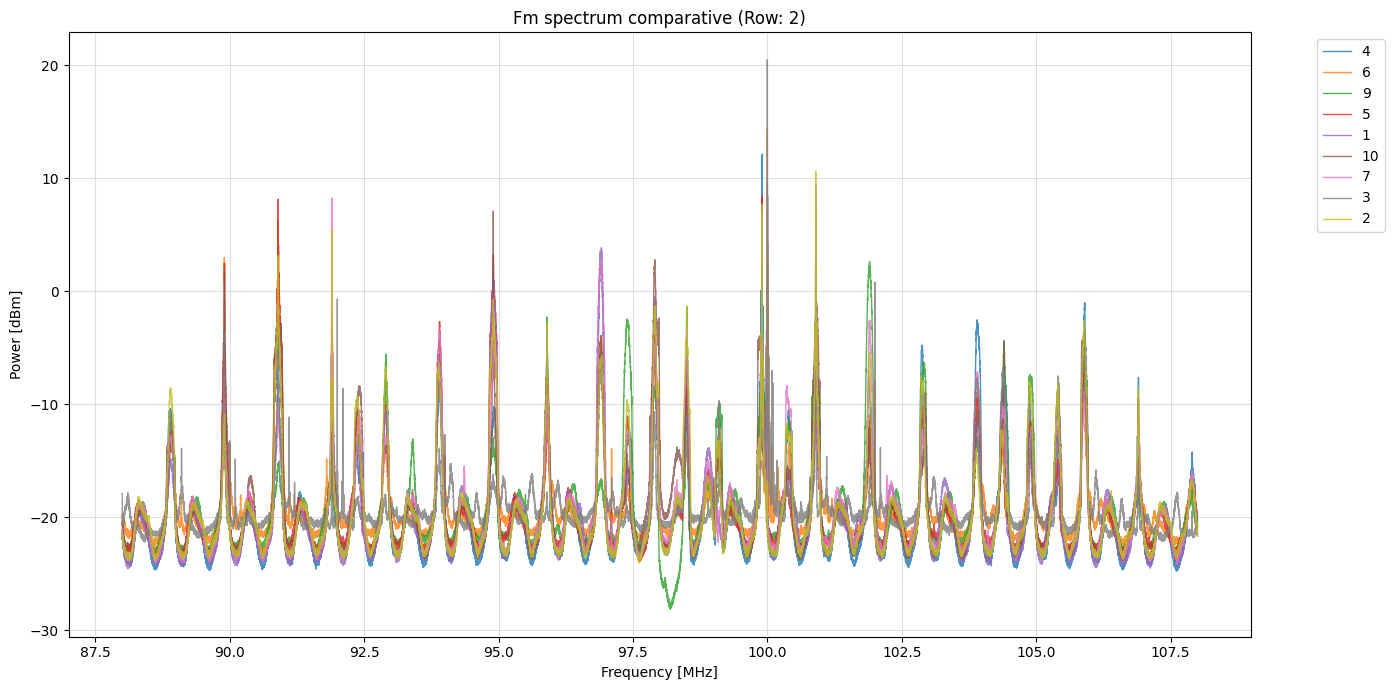

In [15]:
ROW_PLOT = 2  

plt.figure(figsize=(14, 7))

for node_name, df in nodes_data.items():
    pxx = ast.literal_eval(df['pxx'].iloc[ROW_PLOT])
    start_freq = df['start_freq_hz'].iloc[ROW_PLOT]
    end_freq = df['end_freq_hz'].iloc[ROW_PLOT]
    freq = np.linspace(start_freq/1e6, end_freq/1e6, len(pxx))
    
    plt.plot(freq, pxx, label=node_name, linewidth=1, alpha=0.8)

plt.title(f"Fm spectrum comparative (Row: {ROW_PLOT})")
plt.xlabel("Frequency [MHz]")
plt.ylabel("Power [dBm]")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

# Plotting just one sensor, in this case sensor 1 (All the spectrum of one sensor)

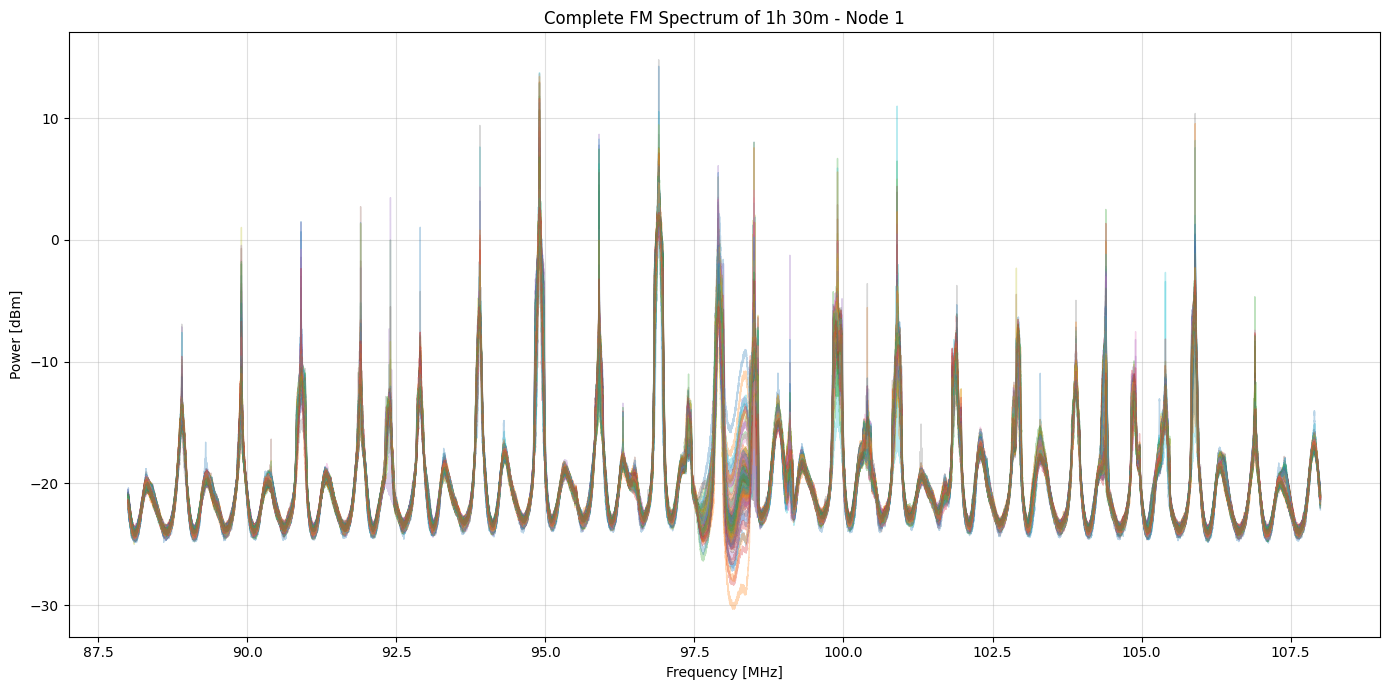

In [16]:
NODE_TO_PLOT = "1"
df = nodes_data[NODE_TO_PLOT]

plt.figure(figsize=(14, 7))

# Loop through all rows of the specific node
for i in range(len(df)):
    pxx = ast.literal_eval(df['pxx'].iloc[i])
    start_freq = df['start_freq_hz'].iloc[i]
    end_freq = df['end_freq_hz'].iloc[i]
    
    freq = np.linspace(start_freq/1e6, end_freq/1e6, len(pxx))
    
    # Using a lower alpha makes overlapping lines easier to see
    plt.plot(freq, pxx, linewidth=1, alpha=0.3)

plt.title(f"Complete FM Spectrum of 1h 30m - Node {NODE_TO_PLOT}")
plt.xlabel("Frequency [MHz]")
plt.ylabel("Power [dBm]")
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()